# 📅 Day 3 of 100 — Indexing, Selecting & Assigning

---

## 🗂️ Agenda
1. Selecting data using **Native Python** (bracket notation)
2. Selecting data using **`loc`** (label-based indexing)
3. Selecting data using **`iloc`** (integer-based indexing)
4. **Conditional Selection** (boolean filtering)
5. **Assigning** new data to a DataFrame

---

## 🎯 Deliverables
- [ ] Select a single column and a single row from a DataFrame
- [ ] Use `loc` to select by label
- [ ] Use `iloc` to select by integer position
- [ ] Filter rows using a condition
- [ ] Assign a new column to a DataFrame

---

## 📚 Learning Topics

| # | Topic | Description |
|---|-------|-------------|
| 1 | Native Indexing | Using `df['col']` and `df['col'][row]` |
| 2 | `loc` | Label-based: `df.loc[row, col]` |
| 3 | `iloc` | Integer-based: `df.iloc[row, col]` |
| 4 | Conditional Selection | `df[df['col'] condition]` |
| 5 | Assigning | `df['new_col'] = value` |



## 🔧 Imports


In [1]:
import pandas as pd
import numpy as np

---

## Step 1 — Read the Dataframe of the wine

In [8]:
#using index_col for (use first column as row index)

wine_review = pd.read_csv(r"C:\Users\aslam\Downloads\winemag-data-130k-v2.csv\winemag-data-130k-v2.csv", index_col=0)
pd.set_option('display.max_rows', 5)
wine_review.head(10)

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8,Germany,Savory dried thyme notes accent sunnier flavor...,Shine,87,12.0,Rheinhessen,NaN,NaN,Anna Lee C. Iijima,NaN,Heinz Eifel 2013 Shine Gewürztraminer (Rheinhe...,Gewürztraminer,Heinz Eifel
9,France,This has great depth of flavor with its fresh ...,Les Natures,87,27.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Jean-Baptiste Adam 2012 Les Natures Pinot Gris...,Pinot Gris,Jean-Baptiste Adam


---

## Step 2 — Selecting specific column 

In [10]:
# using . method
wine_review.country

0            Italy
1         Portugal
            ...   
129969      France
129970      France
Name: country, Length: 129971, dtype: object

In [11]:
# Using [] Mehtod

wine_review['country']

0            Italy
1         Portugal
            ...   
129969      France
129970      France
Name: country, Length: 129971, dtype: object

In [15]:
# using specific element of the column []
#Think of it like:
#Column first → then row

wine_review['country'][0]

'Italy'

---

## Why pandas has loc and iloc



Dot and brackets are nice, but not powerful enough.

For serious data work, pandas gives:

`iloc` → position-based

`loc` → label-based

These are the professional tools.

---
## 1. iloc (index-based selection)
Format: df.iloc[row, column]

### 1.1 Get first row

In [17]:
# Using the iloc ----- Position-Based
# Means:Row at position 0
# All column

wine_review.iloc[0]

country                                                    Italy
description    Aromas include tropical fruit, broom, brimston...
                                     ...                        
variety                                              White Blend
winery                                                   Nicosia
Name: 0, Length: 13, dtype: object

### 1.2 Get first column

In [20]:
# Using the same layout of iloc ---- [row,column] 
# Breakdown:
# : → all rows
# 0 → first column

wine_review.iloc[:,2]

0                          Vulkà Bianco
1                              Avidagos
                      ...              
129969                              NaN
129970    Lieu-dit Harth Cuvée Caroline
Name: designation, Length: 129971, dtype: object

### 1.3 Slicing rows

In [21]:
# Means:
# Rows 0, 1, 2
# Column 0 (country)
# Why only 3?
# Because iloc excludes the last number.

wine_review.iloc[:3,0]

0       Italy
1    Portugal
2          US
Name: country, dtype: object

### 1.4 Selecting Specific rows

In [22]:
# This shows how to select the specific rows 
wine_review.iloc[[1,2,3],0]

1    Portugal
2          US
3          US
Name: country, dtype: object

### 1.5 Negative Indexing

In [26]:
# Using Negative indexing helps in Checking the last updated values
wine_review.iloc[-5:] 

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
129966,Germany,Notes of honeysuckle and cantaloupe sweeten th...,Brauneberger Juffer-Sonnenuhr Spätlese,90,28.0,Mosel,NaN,NaN,Anna Lee C. Iijima,NaN,Dr. H. Thanisch (Erben Müller-Burggraef) 2013 ...,Riesling,Dr. H. Thanisch (Erben Müller-Burggraef)
129967,US,Citation is given as much as a decade of bottl...,NaN,90,75.0,Oregon,Oregon,Oregon Other,Paul Gregutt,@paulgwine,Citation 2004 Pinot Noir (Oregon),Pinot Noir,Citation
129968,France,Well-drained gravel soil gives this wine its c...,Kritt,90,30.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Gresser 2013 Kritt Gewurztraminer (Als...,Gewürztraminer,Domaine Gresser
129969,France,"A dry style of Pinot Gris, this is crisp with ...",NaN,90,32.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Marcel Deiss 2012 Pinot Gris (Alsace),Pinot Gris,Domaine Marcel Deiss
129970,France,"Big, rich and off-dry, this is powered by inte...",Lieu-dit Harth Cuvée Caroline,90,21.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Schoffit 2012 Lieu-dit Harth Cuvée Car...,Gewürztraminer,Domaine Schoffit


---
## 2. loc (label-based selection)
Format: df.loc[row_label, column_label]

In [30]:
# select row of zero index and the column named as country
wine_review.loc[0,'country']

'Italy'

In [31]:
# select the row with zero index and then the specific column names
wine_review.loc[0,['country', 'description', 'points']]

country                                                    Italy
description    Aromas include tropical fruit, broom, brimston...
points                                                        87
Name: 0, dtype: object

In [32]:
# Select all columns and then select specific columns using the same loc (local idex selection)
wine_review.loc[:,['country','points','description']]

,country,points,description
0,Italy,87,"Aromas include tropical fruit, broom, brimston..."
1,Portugal,87,"This is ripe and fruity, a wine that is smooth..."
...,...,...,...
129969,France,90,"A dry style of Pinot Gris, this is crisp with ..."
129970,France,90,"Big, rich and off-dry, this is powered by inte..."


Big gotcha: loc vs iloc slicing
iloc (Python style)
df.iloc[0:10]

→ rows 0 to 9

loc (inclusive)
df.loc[0:10]

→ rows 0 to 10

⚠️ This difference causes many bugs.

## Changing the index (advanced but important)

In [33]:
wine_review.set_index("title")

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,variety,winery
title,,,,,,,,,,,,
Nicosia 2013 Vulkà Bianco (Etna),Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,White Blend,Nicosia
Quinta dos Avidagos 2011 Avidagos Red (Douro),Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Portuguese Red,Quinta dos Avidagos
...,...,...,...,...,...,...,...,...,...,...,...,...
Domaine Marcel Deiss 2012 Pinot Gris (Alsace),France,"A dry style of Pinot Gris, this is crisp with ...",NaN,90,32.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Pinot Gris,Domaine Marcel Deiss
Domaine Schoffit 2012 Lieu-dit Harth Cuvée Caroline Gewurztraminer (Alsace),France,"Big, rich and off-dry, this is powered by inte...",Lieu-dit Harth Cuvée Caroline,90,21.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Gewürztraminer,Domaine Schoffit


## Conditional selection (real-world filtering)

### 1 Create a condition

In [35]:
wine_review.country == 'Italy'

0          True
1         False
          ...  
129969    False
129970    False
Name: country, Length: 129971, dtype: bool

### 2 Create a condition using LOC

In [36]:
wine_review.loc[wine_review.country == 'Italy']

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
6,Italy,"Here's a bright, informal red that opens with ...",Belsito,87,16.0,Sicily & Sardinia,Vittoria,NaN,Kerin O’Keefe,@kerinokeefe,Terre di Giurfo 2013 Belsito Frappato (Vittoria),Frappato,Terre di Giurfo
...,...,...,...,...,...,...,...,...,...,...,...,...,...
129961,Italy,"Intense aromas of wild cherry, baking spice, t...",NaN,90,30.0,Sicily & Sardinia,Sicilia,NaN,Kerin O’Keefe,@kerinokeefe,COS 2013 Frappato (Sicilia),Frappato,COS
129962,Italy,"Blackberry, cassis, grilled herb and toasted a...",Sàgana Tenuta San Giacomo,90,40.0,Sicily & Sardinia,Sicilia,NaN,Kerin O’Keefe,@kerinokeefe,Cusumano 2012 Sàgana Tenuta San Giacomo Nero d...,Nero d'Avola,Cusumano


### 3 Multiple conditions (AND)

In [39]:
# This clearly shows the Wines from ilaly and the wines have the points greater than or equal to 90
wine_review.loc[
    (wine_review.country == 'Italy') & (wine_review.points >= 90)
]

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
120,Italy,"Slightly backward, particularly given the vint...",Bricco Rocche Prapó,92,70.0,Piedmont,Barolo,NaN,NaN,NaN,Ceretto 2003 Bricco Rocche Prapó (Barolo),Nebbiolo,Ceretto
130,Italy,"At the first it was quite muted and subdued, b...",Bricco Rocche Brunate,91,70.0,Piedmont,Barolo,NaN,NaN,NaN,Ceretto 2003 Bricco Rocche Brunate (Barolo),Nebbiolo,Ceretto
...,...,...,...,...,...,...,...,...,...,...,...,...,...
129961,Italy,"Intense aromas of wild cherry, baking spice, t...",NaN,90,30.0,Sicily & Sardinia,Sicilia,NaN,Kerin O’Keefe,@kerinokeefe,COS 2013 Frappato (Sicilia),Frappato,COS
129962,Italy,"Blackberry, cassis, grilled herb and toasted a...",Sàgana Tenuta San Giacomo,90,40.0,Sicily & Sardinia,Sicilia,NaN,Kerin O’Keefe,@kerinokeefe,Cusumano 2012 Sàgana Tenuta San Giacomo Nero d...,Nero d'Avola,Cusumano


### 4 OR condition

In [41]:
# This clearly shows either show the wine from itly or the wines having point equal to or greater than 90

wine_review.loc[
    (wine_review.country == 'Italy') | (wine_review.points >= 90)
]

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
6,Italy,"Here's a bright, informal red that opens with ...",Belsito,87,16.0,Sicily & Sardinia,Vittoria,NaN,Kerin O’Keefe,@kerinokeefe,Terre di Giurfo 2013 Belsito Frappato (Vittoria),Frappato,Terre di Giurfo
...,...,...,...,...,...,...,...,...,...,...,...,...,...
129969,France,"A dry style of Pinot Gris, this is crisp with ...",NaN,90,32.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Marcel Deiss 2012 Pinot Gris (Alsace),Pinot Gris,Domaine Marcel Deiss
129970,France,"Big, rich and off-dry, this is powered by inte...",Lieu-dit Harth Cuvée Caroline,90,21.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Schoffit 2012 Lieu-dit Harth Cuvée Car...,Gewürztraminer,Domaine Schoffit


### 5 isin() – cleaner multi-value filtering

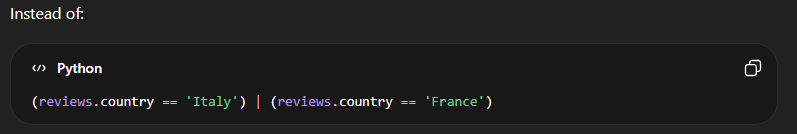

In [44]:
(wine_review.country == 'Italy') | (wine_review.country == 'France')

0          True
1         False
          ...  
129969     True
129970     True
Name: country, Length: 129971, dtype: bool

In [43]:
# Wines from italy or France

wine_review.country.isin(['Italy', 'France'])

0          True
1         False
          ...  
129969     True
129970     True
Name: country, Length: 129971, dtype: bool

### 6 Handling Missing Values
#### notnull()

In [46]:
# Meaning:
# Keep rows where price exists
# Drop rows with NaN prices

wine_review.loc[wine_review.price.notnull()]

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
...,...,...,...,...,...,...,...,...,...,...,...,...,...
129969,France,"A dry style of Pinot Gris, this is crisp with ...",NaN,90,32.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Marcel Deiss 2012 Pinot Gris (Alsace),Pinot Gris,Domaine Marcel Deiss
129970,France,"Big, rich and off-dry, this is powered by inte...",Lieu-dit Harth Cuvée Caroline,90,21.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Schoffit 2012 Lieu-dit Harth Cuvée Car...,Gewürztraminer,Domaine Schoffit


### 7 Assigning New Column 

In [ ]:
# Creating new Column

wine_review['critic'] = 'everyone'

In [48]:
wine_review

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery,critic
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia,everyone
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos,everyone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129969,France,"A dry style of Pinot Gris, this is crisp with ...",NaN,90,32.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Marcel Deiss 2012 Pinot Gris (Alsace),Pinot Gris,Domaine Marcel Deiss,everyone
129970,France,"Big, rich and off-dry, this is powered by inte...",Lieu-dit Harth Cuvée Caroline,90,21.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Schoffit 2012 Lieu-dit Harth Cuvée Car...,Gewürztraminer,Domaine Schoffit,everyone


---

## 🔑 Key Takeaways

- **Native indexing** (`df['col']`) is fine for quick column access, but can get confusing for rows
- **`loc`** selects by **label** — the end of a slice is **inclusive**
- **`iloc`** selects by **integer position** — the end of a slice is **exclusive** (standard Python)
- When in doubt, **prefer `loc` and `iloc`** over chained bracket notation — they are more explicit and less error-prone
- **Conditional selection** uses boolean arrays — always wrap conditions in `()` when combining with `&` or `|`
- **Assigning** a new column is as simple as `df['new_col'] = value` — pandas handles alignment automatically

---

## 🏁 Conclusion

Today we covered **the most essential skill in pandas — getting data in and out of a DataFrame**. Indexing and selection with `loc` and `iloc` are the backbone of every data analysis workflow, and understanding the difference between label-based and position-based selection will save you from countless bugs.

Combined with conditional filtering and column assignment, you now have everything you need to **slice, filter, and enrich** any DataFrame. From Day 5 onwards, we will use these tools constantly as we move into data cleaning and transformation.

---


## ✅ Day 3 Complete — 97 days to go!